# MABSTRUCT GAMESTUDIO STUDY SHEET

implementing game studio via LangGraph study

## MABSTRUCT GAMESTUDIO CONCEPT

PRODUCER --> IDEATION --> DESIGN --> DEVELOP <--> TEST --> DEPLOYMENT


In [32]:
# Imports and environment first, as always

import os
import operator
import random
import requests
import uuid
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field
from typing import List

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.agents import create_agent



load_dotenv(override=True)

True

In [33]:
from langsmith import utils

utils.get_env_var.cache_clear()  # clear stale notebook cache

print("tracing:", utils.get_env_var("TRACING") or utils.get_env_var("TRACING_V2"))
print("project:", utils.get_env_var("PROJECT"))
print("endpoint:", utils.get_env_var("ENDPOINT"))
print("api key set:", bool(utils.get_env_var("API_KEY")))

tracing: true
project: GAMESTUDIO-STUDY
endpoint: https://eu.api.smith.langchain.com
api key set: True


In [34]:
# Getting the Telegram bot token and chat ID from environment variables
# You can also replace these with your actual values directly

TELEGRAM_BOT_TOKEN = os.getenv("TELEGRAM_BOT_TOKEN", "your_bot_token_here")
TELEGRAM_CHAT_ID = os.getenv("TELEGRAM_CHAT_ID", "your_chat_id_here")

### verify TELEGRAM token and chat_id are there

if TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID:
    print("TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found")
else:
    print("TELEGRAM_BOT_TOKEN or TELEGRAM_CHAT_ID not found")



TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found


In [35]:
def send_telegram_message(text):
    url = f"https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage"
    payload = {"chat_id": TELEGRAM_CHAT_ID, "text": text}
    response = requests.post(url, data=payload)

    if response.status_code == 200:
        # print("Message sent successfully!")
        return {"status": "success", "message": text}
    else:
        # print(f"Failed to send message. Status code: {response.status_code}")
        # print(response.text)
        return {"status": "error", "message": response.text}

In [13]:
llm = ChatOpenAI(model="gpt-5.4-mini")


## Adding tools


Adding Tavily Search.

Adding Telegram Push Tool.

In [36]:
from langchain_tavily import TavilySearch
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

search = TavilySearch(max_results=5)

@tool
def send_push_notification(text: str) -> str:
    """Send a short push notification to the user's phone."""
    send_telegram_message(text)
    return "Notification sent"

tools = [search, send_push_notification]
llm_with_tools = llm.bind_tools(tools)

## Adding structured types



In [38]:
class GameIdea(BaseModel):
    """ a conceptual game idea """
    idea_id: str = Field(default="", description="Unique id assigned after ideation (not from the LLM)")
    sub_title: str = Field(description="a sub title for the game that triggers attention or interest to the player")
    genre: str = Field(description="game genre")
    style: str = Field(description="game style")
    reason: str = Field(description="reason why this idea is interesting and why it should be made")
    description: str = Field(description="an abstract to communicate the main idea of the game")
    features: list[str] = Field(description="features of the game")

class GameIdeaList(BaseModel):
    """ a list of game ideas """
    ideas: list[GameIdea] = Field(description="list of game ideas")

#class State(TypedDict):
#    title: str = Field(description="title of the game")
#    ideas: GameIdeaList = Field(description="list of game ideas")



In [39]:
LLM_IDEATION_MODEL = ChatOpenAI(model="gpt-5.6-sol", reasoning_effort="none")
# LLM_IDEATION_MODEL = "anthropic:claude-opus-5"

LLM_DESIGN_MODEL = ChatOpenAI(model="gpt-5.6-terra", reasoning_effort="none")
# LLM_DESIGN_MODEL = "anthropic:claude-opus-5"

# Develop needs many tool steps (start + js chunks + end + verify); use Anthropic native client.
LLM_DEVELOP_MODEL = "anthropic:claude-opus-5"
DEVELOP_RECURSION_LIMIT = 100


## Ideation Agent

### Calling the simple agent

In [43]:
# OpenAI reasoning models: ChatOpenAI(..., reasoning_effort="none") when using tools.
# Anthropic: use ChatAnthropic (or the string "anthropic:claude-opus-4-6"), not ChatOpenAI.


# GAME_TITLE = "The Big Swallow"

MABSTRUCT_GAMESTUDIO_NAME = "MABSTRUCT GAMESTUDIO"

MABSTRUCT_GAMESTUDIO_BACKGROUNDER = f"""{MABSTRUCT_GAMESTUDIO_NAME}:
The studio concentrates on creating single player browser games.
The attitude of the games is creative, inventive and innovative and is slightly surreal 
and concentrated on sci-fi and cosmic themes.
"""

IDEATION_SYSTEM_PROMPT = """
You are an experienced Creative Strategist for web browser games for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
You have a strong background in browser games ideation and design.
You bring a wealth of knowledge about single player web browser games.
You are the one to bring back the best game ideas to the production team of the game studio.
You are known for your ability to create engaging, creative and fun browser games
that are both challenging and fun to play. You typically research the web for the latest trends and best games.
Genre, style, sub title and other criteria should be inventive. We are exploring game ideas.
These ideas will be later refined by the production and design team.
"""

IDEATION_HUMAN_PROMPT = """
Here is the new game title: {GAME_TITLE}.
Develop a list of 5 game ideas that are related to the game title.
Do not come back with less then 5 ideas.
For each game idea, provide a short description and the reason why this works for the studio.
You can also search the web for the latest trends and interesting new games.
"""

system_message = SystemMessage(IDEATION_SYSTEM_PROMPT)
human_message = HumanMessage(IDEATION_HUMAN_PROMPT)

messages_input = [
    human_message,
]

ideation_agent = create_agent(
    model=LLM_IDEATION_MODEL,
    system_prompt=IDEATION_SYSTEM_PROMPT,
    tools=[search],
    response_format=GameIdeaList,
)

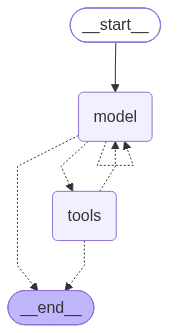

In [44]:
ideation_agent

### now let us create a first graph

In [45]:
class GameDesignBrief(BaseModel):
    """
    The brief for the game.
    """
    game_title: str = Field(description="The title of the game")
    game_sub_title: str = Field(description="The sub title of the game")
    game_description: str = Field(description="A short description of the game in 2 to 5 sentences.")
    game_genre: str = Field(description="The genre of the game")
    game_theme: str = Field(description="The theme of the game")
    game_style: str = Field(description="The style of the game")
    game_mechanics: str = Field(description="The mechanics of the game")
    game_mood: str = Field(description="The mood of the game")
    game_sound: str = Field(description="The sound of the game")
    game_art: str = Field(description="Describe the distinctive creative art and style of the game")
    hints_for_the_team: str = Field(description="Hints and additional information for the production and design team")


class GameDesignRecord(BaseModel):
    """Design brief linked to one ideation idea."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    brief: GameDesignBrief


class DesignJob(TypedDict):
    """Input passed to each design worker via Send."""
    game_title: str
    idea_id: str
    idea: GameIdea


class GameDevelopRecord(BaseModel):
    """Built HTML game linked to one design brief."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    html_path: str = Field(description="Path to the written index.html")
    tier0_pass: bool = Field(description="Whether static Tier-0 validation passed")
    summary: str = Field(description="Developer confirmation: MVP vs deferred, validation notes")


class DevelopJob(TypedDict):
    """Input passed to each parallel develop worker via Send."""
    game_title: str
    idea_id: str
    brief: GameDesignBrief


class GameTestRecord(BaseModel):
    """Automated Tier-0/Tier-1 results for one built game."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    html_path: str = Field(description="Path to index.html that was tested")
    json_path: str = Field(description="Path to written game_testing.json")
    overall: str = Field(description="pass or fail — deployment gate reads this")
    tier0_pass: bool
    tier1_pass: bool | None = Field(description="None when Tier-1 skipped (Tier-0 failed)")
    blocked: bool = Field(description="True when Tier-1 was skipped due to Tier-0 failure")
    issues: list[str] = Field(default_factory=list, description="Combined tier0/tier1 issues")


class TestJob(TypedDict):
    """Input passed to each parallel test worker via Send."""
    game_title: str
    idea_id: str
    html_path: str


class GameStudioState(TypedDict):
    """
    The development state of the game studio.
    """
    game_title: str
    game_ideation: GameIdeaList | None
    game_designs: Annotated[list[GameDesignRecord], operator.add]
    game_developments: Annotated[list[GameDevelopRecord], operator.add]
    game_tests: Annotated[list[GameTestRecord], operator.add]
    game_html_path: str | None
    test_result: dict | None      # optional aggregate; per-idea results in game_tests
    deployment_url: str | None

In [ ]:
GAME_TITLE = "The Big Swallow"

initial_state: GameStudioState = {
    "game_title": GAME_TITLE,
    "game_ideation": None,
    "game_designs": [],
    "game_developments": [],
    "game_tests": [],
    "game_html_path": None,
    "test_result": None,
    "deployment_url": None,
}

print(initial_state)

{'game_title': {'The Big Swallow'}, 'game_ideation': None, 'game_designs': [], 'game_developments': [], 'game_tests': [], 'game_html_path': None, 'test_result': None, 'deployment_url': None}


In [28]:
def ideation_node(state: GameStudioState) -> dict:
    prompt = IDEATION_HUMAN_PROMPT.format(GAME_TITLE=state["game_title"])
    agent_result = ideation_agent.invoke({
        "messages": [HumanMessage(content=prompt)]
    })
    ideas = agent_result["structured_response"].ideas
    tagged_ideas = [
        idea.model_copy(update={"idea_id": str(uuid.uuid4())})
        for idea in ideas
    ]
    return {"game_ideation": GameIdeaList(ideas=tagged_ideas)}

### most simple graph with only one node

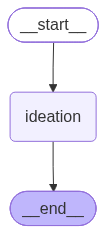

In [29]:
builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
builder.add_edge(START, "ideation")
builder.add_edge("ideation", END)
studio = builder.compile()

display(Image(studio.get_graph().draw_mermaid_png()))

In [30]:
result = studio.invoke(initial_state)
game_ideation = result["game_ideation"]

for idea in game_ideation.ideas:
    print(idea.sub_title)
    print(idea.description)
    print(idea.reason)
    print(idea.features)
    print(idea.genre)
    print(idea.style)
    print("-" * 100)


Eat the World Before It Eats You
Control a tiny interdimensional mouth trapped in arenas full of food, monsters, traps, and rival predators. Swallow smaller targets to grow, then consume enemies that were previously threats. Each meal fills a mutation meter, offering upgrades such as orbiting teeth, vacuum breath, explosive burps, or a second mouth. The objective is to become large enough to swallow the arena boss before an encroaching cosmic predator arrives.
The instantly understood “eat smaller, avoid bigger” rule is ideal for browser play, while roguelite mutations add replayability and meaningful progression. One-thumb or mouse controls keep production focused, and spectacular size changes create highly shareable moments.
['Fast 8–12 minute procedural runs', 'Clear size-based food-chain system', 'Branching mutation upgrades and build synergies', 'Destructible arenas that change as the player grows', 'Bosses designed as edible multi-stage environments', 'Daily seeded challenge and 

### a graph with two nodes (ideation & design)

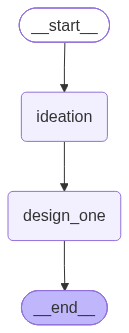

In [41]:


DESIGN_SYSTEM_PROMPT = """
You are an experienced Creative Strategist for web browser games for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
You have a strong background in browser games ideation and design.
You bring a wealth of knowledge about single player web browser games.
You are the one to bring back the best game ideas to the production team of the game studio.
You are known for your ability to create engaging, creative and fun browser games.
This game design will be given to the production team to develop the game.
You are allowed to search the web for the latest trends and ideas.
"""

DESIGN_HUMAN_PROMPT = """
The task is to develop a game design brief for the following game:
The game title is {GAME_TITLE}.
The game idea is {GAME_IDEA}.
"""


design_agent = create_agent(
    model=LLM_DESIGN_MODEL,
    system_prompt=DESIGN_SYSTEM_PROMPT,
    tools=[search],
    response_format=GameDesignBrief,
)

### TODO DESIGN NODE
def design_node(state: GameStudioState) -> dict:
    prompt = DESIGN_HUMAN_PROMPT.format(GAME_TITLE=state["game_title"])
    agent_result = design_agent.invoke({
        "messages": [HumanMessage(content=prompt)]
    })
    ideas = agent_result["structured_response"].ideas
    tagged_ideas = [
        idea.model_copy(update={"idea_id": str(uuid.uuid4())})
        for idea in ideas
    ]
    return {"game_ideation": GameIdeaList(ideas=tagged_ideas)}


def fan_out_design(state: GameStudioState):
    """Spawn one parallel design worker per idea."""
    if state["game_ideation"] is None:
        return []
    return [
        Send(
            "design_one",
            {
                "game_title": state["game_title"],
                "idea_id": idea.idea_id,
                "idea": idea,
            },
        )
        for idea in state["game_ideation"].ideas
    ]


def design_one(job: DesignJob) -> dict:
    idea = job["idea"]
    prompt = f"""
Game title: {job["game_title"]}

Develop a full game design brief for this specific game idea:

Sub-title: {idea.sub_title}
Genre: {idea.genre}
Style: {idea.style}
Description: {idea.description}
Reason: {idea.reason}
Features: {idea.features}
"""
    agent_result = design_agent.invoke({
        "messages": [HumanMessage(content=prompt)]
    })
    return {
        "game_designs": [
            GameDesignRecord(
                idea_id=job["idea_id"],
                brief=agent_result["structured_response"],
            )
        ]
    }


builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
builder.add_node("design_one", design_node)

builder.add_edge(START, "ideation")
#builder.add_conditional_edges("ideation", fan_out_design)
#builder.add_edge("ideation_and_design", "ideation")
builder.add_edge("ideation", "design_one")
builder.add_edge("design_one", END)

studio = builder.compile()

display(Image(studio.get_graph().draw_mermaid_png()))

In [42]:
result = studio.invoke(initial_state)

print(f"Ideas: {len(result['game_ideation'].ideas)}")
print(f"Designs: {len(result['game_designs'])}")
print()

for record in result["game_designs"]:
    idea = next(i for i in result["game_ideation"].ideas if i.idea_id == record.idea_id)
    print(f"idea_id: {record.idea_id}")
    print(f"idea: {idea.sub_title}")
    print(f"brief: {record.brief.game_sub_title} — {record.brief.game_genre}")
    print("-" * 100)


ValidationError: 5 validation errors for GameIdeaList
ideas.0
  Input should be a valid dictionary or instance of GameIdea [type=model_type, input_value=GameIdea(idea_id='eae31f5...ble swallow-creatures']), input_type=GameIdea]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type
ideas.1
  Input should be a valid dictionary or instance of GameIdea [type=model_type, input_value=GameIdea(idea_id='6e2c7f8...d challenge modifiers']), input_type=GameIdea]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type
ideas.2
  Input should be a valid dictionary or instance of GameIdea [type=model_type, input_value=GameIdea(idea_id='a7cbb2d...ed for short sessions']), input_type=GameIdea]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type
ideas.3
  Input should be a valid dictionary or instance of GameIdea [type=model_type, input_value=GameIdea(idea_id='d12c5f4... with fixed machinery']), input_type=GameIdea]
    For fu

### develop agent + develop_one node

Parallel develop workers mirror `design_one`: each builds `{notebook_dir}/dev-output/{game_title}/{idea_id}/index.html` via chunked HTML tools + Tier-0 validation.

In [150]:
from __future__ import annotations

from pathlib import Path
import re
import subprocess
import tempfile




# Re-run the GameStudioState cell above if this block runs (kernel had stale types).
if "DevelopJob" not in globals():
    class GameDevelopRecord(BaseModel):
        """Built HTML game linked to one design brief."""
        idea_id: str = Field(description="Matches GameIdea.idea_id")
        html_path: str = Field(description="Path to the written index.html")
        tier0_pass: bool = Field(description="Whether static Tier-0 validation passed")
        summary: str = Field(description="Developer confirmation: MVP vs deferred, validation notes")

    class DevelopJob(TypedDict):
        """Input passed to each parallel develop worker via Send."""
        game_title: str
        idea_id: str
        brief: GameDesignBrief

NOTEBOOK_DIR = Path.cwd() / "mabstruct_studio" if (Path.cwd() / "mabstruct_studio" / "mabstruct_study.ipynb").exists() else Path.cwd()
STUDIO_OUTPUT_DIR = NOTEBOOK_DIR / "dev-output"
MAX_JS_CHUNK_CHARS = 6000
SCRIPT_BLOCK_RE = re.compile(
    r"<script(?![^>]*\bsrc=)[^>]*>(.*?)</script>",
    re.IGNORECASE | re.DOTALL,
)


def _game_html_path(game_title: str, idea_id: str) -> Path:
    return STUDIO_OUTPUT_DIR / game_title / idea_id / "index.html"


def run_static_validation(html_path: Path) -> dict:
    """Tier 0: single inline script block + node --check when available."""
    issues: list[str] = []
    checks: dict = {}

    if not html_path.exists():
        return {"pass": False, "issues": [f"missing file: {html_path}"], "checks": checks}

    html = html_path.read_text(encoding="utf-8")
    checks["bytes"] = len(html)
    script_blocks = [
        block.strip()
        for block in SCRIPT_BLOCK_RE.findall(html)
        if block.strip()
    ]
    checks["script_blocks"] = len(script_blocks)
    if len(script_blocks) != 1:
        issues.append(
            f"expected exactly 1 inline <script> block, found {len(script_blocks)}"
        )

    for index, block in enumerate(script_blocks):
        with tempfile.NamedTemporaryFile(
            mode="w", suffix=f"_{index}.js", delete=False, encoding="utf-8"
        ) as tmp:
            tmp.write(block)
            tmp_path = Path(tmp.name)
        try:
            proc = subprocess.run(
                ["node", "--check", str(tmp_path)],
                capture_output=True,
                text=True,
                timeout=10,
            )
            if proc.returncode != 0:
                message = (proc.stderr or proc.stdout or "parse failed").strip()
                issues.append(f"script block {index}: {message}")
        except FileNotFoundError:
            issues.append("node is not installed — cannot run JS parse check")
            break
        except subprocess.TimeoutExpired:
            issues.append(f"script block {index}: node --check timed out")
        finally:
            tmp_path.unlink(missing_ok=True)

    return {"pass": not issues, "issues": issues, "checks": checks}


def make_dev_tools(game_title: str, idea_id: str) -> list:
    """Per-idea HTML assembly tools (safe for parallel develop workers)."""
    buffer: list[str] = []

    @tool
    def write_game_html_part(content: str, part: str) -> str:
        """Assemble a single-file HTML game across start → js chunks → end."""
        nonlocal buffer

        if not content or not str(content).strip():
            return "Write rejected: content is empty."

        normalized = part.strip().lower()
        if normalized not in {"start", "js", "end"}:
            return 'Write rejected: part must be "start", "js", or "end".'

        if normalized in {"start", "js"} and len(content) > MAX_JS_CHUNK_CHARS:
            return (
                f"Write rejected: chunk too large ({len(content)} chars). "
                f"Split into pieces under {MAX_JS_CHUNK_CHARS} characters."
            )

        if normalized == "start":
            buffer.clear()
            lower = content.lower()
            if not lower.lstrip().startswith("<!doctype html"):
                return "Write rejected: start must begin with <!DOCTYPE html>"
            if "<script" not in lower:
                return "Write rejected: start must open exactly one <script> block"
            if "</script>" in lower or "</html>" in lower:
                return (
                    "Write rejected: start must NOT close </script> or </html>. "
                    "Use part=js for code and part=end for closing tags."
                )
            buffer.append(content)
            return f"Buffered start ({len(content)} chars). Next: part=js, then part=end."

        if normalized == "js":
            if not buffer:
                return "Write rejected: call part=start before part=js."
            lower = content.lower()
            for tag in ("<script", "</script>", "</html>", "<!doctype", "</body>", "<body"):
                if tag in lower:
                    return f"Write rejected: js part must be raw JavaScript only (found {tag})."
            buffer.append(content)
            total = sum(len(piece) for piece in buffer)
            return f"Buffered js ({len(content)} chars). Assembly total: {total} chars."

        if not buffer:
            return "Write rejected: call part=start before part=end."
        lower = content.lower()
        if "</script>" not in lower or "</html>" not in lower:
            return "Write rejected: end must include </script></body></html>."

        buffer.append(content)
        full = "".join(buffer)
        path = _game_html_path(game_title, idea_id)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(full, encoding="utf-8")
        buffer.clear()

        validation = run_static_validation(path)
        status = "PASS" if validation["pass"] else "FAIL"
        lines = [
            f"Wrote {path} ({len(full)} bytes)",
            f"Tier-0 validation: {status}",
        ]
        if validation["issues"]:
            lines.append("Issues: " + "; ".join(validation["issues"]))
        elif validation["pass"]:
            lines.append("Single inline script block parsed successfully.")
        if not validation["pass"]:
            lines.append("Fix issues and rewrite using part=start again.")
        return "\n".join(lines)

    @tool
    def verify_game_html() -> str:
        """Run Tier-0 validation on the current idea's index.html."""
        path = _game_html_path(game_title, idea_id)
        validation = run_static_validation(path)
        status = "PASS" if validation["pass"] else "FAIL"
        lines = [f"Tier-0 validation: {status}", f"File: {path}"]
        if validation["issues"]:
            lines.append("Issues:")
            lines.extend(f"- {issue}" for issue in validation["issues"])
        return "\n".join(lines)

    return [write_game_html_part, verify_game_html]


DEVELOP_SYSTEM_PROMPT = f"""
You are an experienced Browser Game Developer for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
Build a complete single-file HTML5 Canvas game (inline CSS + vanilla JS).
Architecture requirements:
- Exactly ONE inline <script> block for all JavaScript
- Separate update(dt, state) from render(state) where possible
- Multiply physics by dt (frame-rate independent)
- Implement MVP scope only; list deferred items honestly in your final answer
Writing (use write_game_html_part tool only — never paste HTML in chat):
1. part=start: <!DOCTYPE html> through opening <script> (no </script> or </html> yet)
2. part=js: raw JavaScript chunks only (repeat 4-8 times, each under 6000 chars)
3. part=end: final JS plus </script></body></html> — this writes the file
After part=end, call verify_game_html. If Tier-0 FAIL, rewrite from part=start.
Final answer: short confirmation with path, byte size, Tier-0 status, MVP vs deferred list.
"""


def _message_text(message) -> str:
    """Plain text from AIMessage; Opus may return thinking blocks as a list."""
    content = message.content
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts: list[str] = []
        for block in content:
            if isinstance(block, dict) and block.get("type") == "text":
                parts.append(block.get("text", ""))
            elif isinstance(block, str):
                parts.append(block)
        return "\n".join(part for part in parts if part)
    return str(content)


def _tool_names_from_messages(messages) -> list[str]:
    names: list[str] = []
    for msg in messages:
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            names.append(tc.get("name", "?"))
    return names


def develop_one(job: DevelopJob) -> dict:
    """Parallel develop worker — one HTML game per design brief."""
    brief = job["brief"]
    tools = make_dev_tools(job["game_title"], job["idea_id"])
    develop_agent = create_agent(
        model=LLM_DEVELOP_MODEL,
        system_prompt=DEVELOP_SYSTEM_PROMPT,
        tools=tools,
    )
    prompt = f"""
Game title: {job["game_title"]}
Idea id: {job["idea_id"]}

Develop this browser game from the design brief below.

Sub-title: {brief.game_sub_title}
Genre: {brief.game_genre}
Theme: {brief.game_theme}
Style: {brief.game_style}
Description: {brief.game_description}
Mechanics: {brief.game_mechanics}
Mood: {brief.game_mood}
Sound: {brief.game_sound}
Art: {brief.game_art}
Hints for the team: {brief.hints_for_the_team}
"""
    html_path = _game_html_path(job["game_title"], job["idea_id"])
    agent_config = {"recursion_limit": DEVELOP_RECURSION_LIMIT}
    messages = [HumanMessage(content=prompt)]
    retry_note = (
        "CRITICAL: index.html was NOT written. Use write_game_html_part only — "
        "part=start, then part=js (repeat 4-8 times), then part=end to write the file. "
        "Then call verify_game_html. Do not paste HTML in chat."
    )

    agent_result = None
    for attempt in range(2):
        agent_result = develop_agent.invoke(
            {"messages": messages},
            config=agent_config,
        )
        if html_path.exists():
            break
        if attempt == 0:
            messages = list(agent_result["messages"]) + [HumanMessage(content=retry_note)]

    validation = (
        run_static_validation(html_path)
        if html_path.exists()
        else {"pass": False, "issues": ["file not written"]}
    )
    tool_names = _tool_names_from_messages(agent_result["messages"])
    summary = _message_text(agent_result["messages"][-1])
    if not validation["pass"]:
        summary = (
            f"{summary}\n\nTier-0 issues: {'; '.join(validation['issues'])}\n"
            f"Tools called: {tool_names or ['none']}"
        )
    return {
        "game_developments": [
            GameDevelopRecord(
                idea_id=job["idea_id"],
                html_path=str(html_path.resolve()),
                tier0_pass=validation["pass"],
                summary=summary,
            )
        ]
    }


def fan_out_develop(state: GameStudioState):
    """Spawn one parallel develop worker per completed design brief."""
    return [
        Send(
            "develop_one",
            {
                "game_title": state["game_title"],
                "idea_id": record.idea_id,
                "brief": record.brief,
            },
        )
        for record in state["game_designs"]
    ]


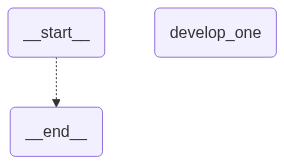

In [151]:
dev_builder = StateGraph(GameStudioState)

dev_builder.add_node("develop_one", develop_one)

dev_builder.add_conditional_edges(START, fan_out_develop)
dev_builder.add_edge("develop_one", END)

studio_dev = dev_builder.compile()

display(Image(studio_dev.get_graph().draw_mermaid_png()))

In [152]:
# Re-use design-phase result as input (must have game_designs populated)
print(f"Develop output root: {STUDIO_OUTPUT_DIR.resolve()}")

# TODO: stick to one development, go into the loop later again
dev_result = studio_dev.invoke({**dev_result, "game_designs": dev_result["game_designs"][:1]})
# dev_result = studio_dev.invoke(result)



print(f"Designs: {len(dev_result['game_designs'])}")
print(f"Developments: {len(dev_result['game_developments'])}")
print()

for dev in dev_result["game_developments"]:
    design = next(d for d in dev_result["game_designs"] if d.idea_id == dev.idea_id)
    html_path = Path(dev.html_path)
    print(f"idea_id: {dev.idea_id}")
    print(f"design: {design.brief.game_sub_title}")
    print(f"html: {html_path}")
    print(f"exists: {html_path.exists()}")
    print(f"tier0: {dev.tier0_pass}")
    if html_path.exists() and not dev.tier0_pass:
        v = run_static_validation(html_path)
        print(f"tier0 issues: {v['issues']}")
    elif not html_path.exists():
        print("tier0 issues: file not written (agent did not call write_game_html_part part=end)")
    print(f"summary: {dev.summary[:400]}")
    print("-" * 100)

Develop output root: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output
Designs: 1
Developments: 7

idea_id: 1953d2b8-a767-4fbb-afd0-a840606a0866
design: Eat the City Before It Eats You
html: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output/The Big Swallow/1953d2b8-a767-4fbb-afd0-a840606a0866/index.html
exists: True
tier0: False
tier0 issues: []
summary: 
----------------------------------------------------------------------------------------------------


StopIteration: 

### test node + test_one worker

Parallel test workers mirror `develop_one`: each runs **Tier-0** (structure + JS parse) and **Tier-1** (Node smoke harness boot + start-button click), then writes `{dev-output}/{game_title}/{idea_id}/game_testing.json` — same contract as the CrewAI `Run game tests` tool.

In [153]:
import json

# Re-run GameStudioState cell above if TestJob / GameTestRecord are missing.
if "TestJob" not in globals():
    class GameTestRecord(BaseModel):
        idea_id: str
        html_path: str
        json_path: str
        overall: str
        tier0_pass: bool
        tier1_pass: bool | None
        blocked: bool
        issues: list[str] = Field(default_factory=list)

    class TestJob(TypedDict):
        game_title: str
        idea_id: str
        html_path: str

SMOKE_SCRIPT = NOTEBOOK_DIR / "scripts" / "game_smoke_test.mjs"


def _game_testing_json_path(game_title: str, idea_id: str) -> Path:
    return STUDIO_OUTPUT_DIR / game_title / idea_id / "game_testing.json"


def extract_inline_script_blocks(html: str) -> list[str]:
    return [
        block.strip()
        for block in SCRIPT_BLOCK_RE.findall(html)
        if block.strip()
    ]


def run_static_validation_full(html_path: Path) -> dict:
    """Tier 0: full structure + JS parse checks (CrewAI game_validation.py parity)."""
    issues: list[str] = []
    checks: dict = {}

    if not html_path.exists():
        return {
            "tier": 0,
            "pass": False,
            "issues": [f"missing file: {html_path}"],
            "checks": checks,
        }

    html = html_path.read_text(encoding="utf-8")
    stripped = html.rstrip()
    checks["bytes"] = len(html)
    checks["lines"] = html.count("\n") + 1

    if not stripped.lower().startswith("<!doctype html") and not stripped.lower().startswith("<html"):
        issues.append("file must start with <!DOCTYPE html> or <html>")

    script_blocks = extract_inline_script_blocks(html)
    checks["script_blocks"] = len(script_blocks)
    if len(script_blocks) != 1:
        issues.append(
            f"expected exactly 1 inline <script> block, found {len(script_blocks)}"
        )

    html_close = stripped.lower().find("</html>")
    if html_close == -1:
        issues.append("missing closing </html>")
    elif html_close < len(stripped) - len("</html>"):
        trailing = stripped[html_close + len("</html>") :].strip()
        if trailing:
            issues.append("content appears after first </html> (chunk assembly bug)")

    body_closes = len(re.findall(r"</body>", stripped, re.IGNORECASE))
    html_closes = len(re.findall(r"</html>", stripped, re.IGNORECASE))
    checks["body_closes"] = body_closes
    checks["html_closes"] = html_closes
    if body_closes != 1:
        issues.append(f"expected exactly 1 </body>, found {body_closes}")
    if html_closes != 1:
        issues.append(f"expected exactly 1 </html>, found {html_closes}")

    if re.search(r'\bsrc\s*=\s*["\']https?://', html, re.IGNORECASE):
        issues.append("external script/src references found in single-file deliverable")

    parse_errors: list[str] = []
    for index, block in enumerate(script_blocks):
        with tempfile.NamedTemporaryFile(
            mode="w", suffix=f"_{index}.js", delete=False, encoding="utf-8"
        ) as tmp:
            tmp.write(block)
            tmp_path = Path(tmp.name)
        try:
            proc = subprocess.run(
                ["node", "--check", str(tmp_path)],
                capture_output=True,
                text=True,
                timeout=10,
            )
            if proc.returncode != 0:
                message = (proc.stderr or proc.stdout or "parse failed").strip()
                parse_errors.append(f"script block {index}: {message}")
        except FileNotFoundError:
            parse_errors.append("node is not installed — cannot run JS parse check")
            break
        except subprocess.TimeoutExpired:
            parse_errors.append(f"script block {index}: node --check timed out")
        finally:
            tmp_path.unlink(missing_ok=True)

    checks["js_parse_ok"] = not parse_errors
    issues.extend(parse_errors)

    return {"tier": 0, "pass": not issues, "issues": issues, "checks": checks}


def run_smoke_test(html_path: Path, smoke_script: Path = SMOKE_SCRIPT) -> dict:
    """Tier 1: headless boot + start-button click via Node harness."""
    if not smoke_script.exists():
        return {
            "tier": 1,
            "pass": False,
            "issues": [f"missing smoke harness: {smoke_script}"],
            "checks": {},
        }

    try:
        proc = subprocess.run(
            ["node", str(smoke_script), str(html_path)],
            capture_output=True,
            text=True,
            timeout=30,
        )
    except FileNotFoundError:
        return {
            "tier": 1,
            "pass": False,
            "issues": ["node is not installed — cannot run smoke test"],
            "checks": {},
        }
    except subprocess.TimeoutExpired:
        return {
            "tier": 1,
            "pass": False,
            "issues": ["smoke test timed out after 30s"],
            "checks": {},
        }

    stdout = proc.stdout.strip()
    if not stdout:
        stderr = (proc.stderr or "no output from smoke harness").strip()
        return {
            "tier": 1,
            "pass": False,
            "issues": [f"smoke harness failed: {stderr}"],
            "checks": {"exit_code": proc.returncode},
        }

    try:
        payload = json.loads(stdout)
    except json.JSONDecodeError:
        return {
            "tier": 1,
            "pass": False,
            "issues": [f"invalid smoke harness JSON: {stdout[:200]}"],
            "checks": {"exit_code": proc.returncode},
        }

    payload["tier"] = 1
    if "pass" not in payload:
        payload["pass"] = proc.returncode == 0 and not payload.get("issues")
    return payload


def run_all_game_tests(html_path: Path, smoke_script: Path = SMOKE_SCRIPT) -> dict:
    """Run Tier-0 then Tier-1; return game_testing.json payload."""
    tier0 = run_static_validation_full(html_path)
    tier1: dict | None = None
    if tier0["pass"]:
        tier1 = run_smoke_test(html_path, smoke_script)

    overall_pass = tier0["pass"] and bool(tier1 and tier1.get("pass"))
    blocked = not tier0["pass"] and tier1 is None

    return {
        "overall": "pass" if overall_pass else "fail",
        "blocked": blocked,
        "artifact": str(html_path),
        "tier0": tier0,
        "tier1": tier1,
    }


def write_test_report(report_path: Path, report: dict) -> None:
    report_path.parent.mkdir(parents=True, exist_ok=True)
    report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")


def check_deployment_gate(json_path: Path, html_path: Path) -> str:
    """Mirror CrewAI Check deployment gate — DEPLOY ALLOWED only when overall=pass."""
    if not json_path.exists():
        return (
            "DEPLOY BLOCKED: missing game_testing.json. "
            "Run game tests must pass before deployment."
        )

    report = json.loads(json_path.read_text(encoding="utf-8"))
    overall = report.get("overall")
    if overall != "pass":
        tier0 = report.get("tier0", {})
        tier1 = report.get("tier1") or {}
        return (
            f"DEPLOY BLOCKED: game_testing.json overall={overall}. "
            f"tier0={tier0.get('pass')}, tier1={tier1.get('pass')}. "
            "Send the game back to development/testing."
        )

    if not html_path.exists():
        return f"DEPLOY BLOCKED: missing {html_path}"

    return (
        "DEPLOY ALLOWED: game_testing.json overall=pass. "
        f"Artifact: {html_path}"
    )


def _collect_issues(report: dict) -> list[str]:
    issues: list[str] = []
    tier0 = report.get("tier0") or {}
    tier1 = report.get("tier1") or {}
    issues.extend(tier0.get("issues") or [])
    if tier1:
        issues.extend(tier1.get("issues") or [])
    elif report.get("blocked"):
        issues.append("tier1=skipped (tier0 failed)")
    return issues


def test_one(job: TestJob) -> dict:
    """Parallel test worker — deterministic Tier-0 + Tier-1, writes game_testing.json."""
    html_path = Path(job["html_path"])
    json_path = _game_testing_json_path(job["game_title"], job["idea_id"])

    report = run_all_game_tests(html_path)
    write_test_report(json_path, report)

    tier0 = report["tier0"]
    tier1 = report.get("tier1")
    record = GameTestRecord(
        idea_id=job["idea_id"],
        html_path=str(html_path.resolve()),
        json_path=str(json_path.resolve()),
        overall=report["overall"],
        tier0_pass=bool(tier0.get("pass")),
        tier1_pass=tier1.get("pass") if tier1 else None,
        blocked=bool(report.get("blocked")),
        issues=_collect_issues(report),
    )
    return {"game_tests": [record]}


def fan_out_test(state: GameStudioState):
    """Spawn one parallel test worker per completed development."""
    return [
        Send(
            "test_one",
            {
                "game_title": state["game_title"],
                "idea_id": dev.idea_id,
                "html_path": dev.html_path,
            },
        )
        for dev in state["game_developments"]
    ]

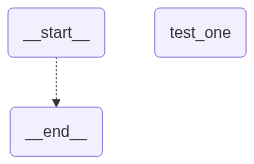

In [154]:
test_builder = StateGraph(GameStudioState)

test_builder.add_node("test_one", test_one)

test_builder.add_conditional_edges(START, fan_out_test)
test_builder.add_edge("test_one", END)

studio_test = test_builder.compile()

display(Image(studio_test.get_graph().draw_mermaid_png()))

In [155]:
# Re-use develop-phase result (must have game_developments populated)
# Run develop first: dev_result = studio_dev.invoke({**design_result, "game_developments": []})

test_input = {
    **dev_result,
    "game_tests": [],
}

# Optional: keep only the latest development per idea_id
if test_input["game_developments"]:
    latest_by_idea: dict[str, GameDevelopRecord] = {}
    for dev in test_input["game_developments"]:
        latest_by_idea[dev.idea_id] = dev
    test_input["game_developments"] = list(latest_by_idea.values())

test_result = studio_test.invoke(test_input)

print(f"Developments tested: {len(test_result['game_tests'])}")
print()

for test in test_result["game_tests"]:
    design = next(
        (d for d in test_result["game_designs"] if d.idea_id == test.idea_id),
        None,
    )
    title = design.brief.game_sub_title if design else test.idea_id
    json_path = Path(test.json_path)
    html_path = Path(test.html_path)

    print(f"idea_id: {test.idea_id}")
    print(f"design: {title}")
    print(f"html: {html_path} (exists={html_path.exists()})")
    print(f"json: {json_path} (exists={json_path.exists()})")
    print(f"overall: {test.overall}")
    print(f"tier0: {test.tier0_pass}")
    print(f"tier1: {test.tier1_pass if test.tier1_pass is not None else 'skipped'}")
    if test.issues:
        print("issues:")
        for issue in test.issues:
            print(f"  - {issue}")
    print(f"gate: {check_deployment_gate(json_path, html_path)}")
    print("-" * 100)

Developments tested: 5

idea_id: 1953d2b8-a767-4fbb-afd0-a840606a0866
design: Eat the City Before It Eats You
html: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output/The Big Swallow/1953d2b8-a767-4fbb-afd0-a840606a0866/index.html (exists=True)
json: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output/The Big Swallow/1953d2b8-a767-4fbb-afd0-a840606a0866/game_testing.json (exists=True)
overall: fail
tier0: True
tier1: False
issues:
  - runtime load error: document.addEventListener is not a function
gate: DEPLOY BLOCKED: game_testing.json overall=fail. tier0=True, tier1=False. Send the game back to development/testing.
----------------------------------------------------------------------------------------------------
idea_id: 9192603e-6ab6-4e6e-8c3c-653cbd8c419c
design: 9192603e-6ab6-4e6e-8c3c-653cbd8c419c
html: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output/The Big Swallow/9192603e-6ab6-4e6e-8c3c-653cbd8c419c/index.html (exists=False)
json: 

## Persisting to SQLite

`MemorySaver` keeps everything in memory, which vanishes when the program stops. For something durable we swap in the SQLite checkpointer, which writes to a database file. The same graph code now survives restarts. A file called `memory.db` appears next to this notebook, and you can delete it whenever you like.

In [ ]:
with SqliteSaver.from_conn_string("memory.db") as sql_memory:
    durable_graph = builder.compile(checkpointer=sql_memory)
    sql_config = {"configurable": {"thread_id": "conversation-2"}}
    durable_graph.invoke({"messages": [{"role": "user", "content": "Remember that my favorite color is orange."}]}, sql_config)
    reply = durable_graph.invoke({"messages": [{"role": "user", "content": "What is my favorite color?"}]}, sql_config)
    print(reply["messages"][-1].content)
    print(reply["spanish"])

## Adding a UI

Let's add a simple Gradio UI to bring this to life. The `chat` function kicks off one run of the graph per message, using a fixed `thread_id` so the conversation is remembered, and it shows the Spanish translation in italics beneath each reply.

In [ ]:
def chat(user_input: str, history):
    config = {"configurable": {"thread_id": "gradio-session4"}}
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    return f"{result['messages'][-1].content}\n\n*{result['spanish']}*"

gr.ChatInterface(chat).launch()

## Recap, and where we are heading

You have built graphs by hand: state with a reducer, nodes, edges, a conditional edge, a tool loop, a second LLM node, observability, memory in two flavors, and a way to inspect and replay the whole thing. This is the machinery that powers everything above it.

Tomorrow we reach Layer 3, our next step along the control to convenience spine. We will ask `create_agent` to build a graph exactly like the tool loop above, in a single line, and then we will render that graph and recognise it as our own.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Add a third tool to the graph, then ask the assistant a question that needs a search followed by a push notification and uses your tool, so the tool loop runs more than once. Then open the LangSmith dashboard, if you turned it on, and trace exactly which nodes ran and in what order.
            </span>
        </td>
    </tr>
</table>